# День 08. Упражнение 04
# Регрессия

## 0. Импорты

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

checker_regression = '../../datasets/checker_regression.csv'

## 1. Предобработка

1. Прочитай файл [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Заполни пропущенные значения нулями (`0`).
3. Раздели набор данных на обучающую и тестовую выборки с параметрами `test_size=0.2`.

In [2]:
df = pd.read_csv(checker_regression)
df.drop(columns="uid", inplace=True)

In [3]:
df.fillna(0, inplace=True)
df = df.drop_duplicates()

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [5]:
X = df.drop(columns="AVG(diff)")
y = df['AVG(diff)']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

## 2. Кросс-валидация

1. Напиши функцию `crossval`, которая принимает аргументы: `n_splits` для `KFold()`, `X`, `y`, модель (инициализированный класс с параметрами модели; не забудь о `random_state=21`) и возвращает для данного класса модели результат в таком виде:

```
train - 2696.4496895424836 | test - 1589.9979527104958
train - 2660.957874001452 | test - 2075.102636027137
train - 2847.315529246795 | test - 320.911928168403
train - 2500.7691099659237 | test - 4132.461382030178
train - 2643.927917295123 | test - 2237.8140952197878
train - 2396.295678819444 | test - 4509.650064742476
train - 2003.402267924976 | test - 8403.491474908551
train - 2531.876094212613 | test - 3135.944102735099
train - 2683.1795186023123 | test - 1796.01426292594
train - 2537.1192483996338 | test - 3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Запусти функцию для моделей `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. Параметры можешь выбрать самостоятельно, но тщательно убедись, что они подходят.

In [6]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    train_scores = []
    test_scores = [] 

    for train_idx, val_idx in kf.split(X):  
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model_clone = model
        model_clone.fit(X_train, y_train)
        
        y_train_pred = model_clone.predict(X_train)
        y_val_pred = model_clone.predict(X_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        
        train_scores.append(train_rmse)
        test_scores.append(val_rmse)
        
        print(f"train - {train_rmse} | test - {val_rmse}")
    
    avg_rmse = np.mean(test_scores)
    print(f"Average RMSE on crossval is {avg_rmse}")
    

In [7]:
lr = LinearRegression()
crossval(5, X, y, lr)

train - 63.13782454059868 | test - 52.69818584468258
train - 58.52936923453279 | test - 79.1236368892683
train - 59.95936162571006 | test - 65.3810266869508
train - 64.09508895095567 | test - 50.49199260444911
train - 56.09722108900308 | test - 82.89345845461484
Average RMSE on crossval is 66.11766009599313


In [8]:
dt = DecisionTreeRegressor(max_depth=5, random_state=21)
crossval(5, X, y, dt)

train - 14.57400343374999 | test - 101.02363218207539
train - 26.166999628639456 | test - 55.85193554124783
train - 11.40679621979809 | test - 65.24139719079756
train - 21.844695779425543 | test - 39.86881907424648
train - 21.75990701360511 | test - 98.99116662331264
Average RMSE on crossval is 72.19539012233597


In [9]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21)
crossval(5, X, y, rf)

train - 18.95525203760634 | test - 86.71506434336587
train - 26.687744606171787 | test - 40.3675250078483
train - 24.192896914132138 | test - 62.675248895633665
train - 25.54482672235929 | test - 41.04648426033901
train - 25.28583439718841 | test - 78.23685143119363
Average RMSE on crossval is 61.808234787676085


## 3. Предсказания и оценка

1. Сделай предсказания на тестовом наборе данных для каждой из трёх моделей с финальными параметрами.
2. Построй график для каждой модели, где по оси x — фактическая средняя разница, а по оси y — предсказание модели.
3. Как должен выглядеть график в идеальном случае? Напиши ответ в markdown-ячейке в конце раздела.

In [10]:
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=5, random_state=21)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=21)

In [11]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",21
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [12]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [13]:
def plot_predictions(model, X_test, y_test, model_name):
 
    y_pred = model.predict(X_test)
    

    sorted_idx = np.argsort(y_test)
    x = y_test.iloc[sorted_idx]  
    y = y_pred[sorted_idx]        
    
  
    plt.figure(figsize=(12, 8))
    
  
    plt.plot(x, y, 'b-', linewidth=2, label='Предсказания модели', alpha=0.7)
    

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', 
             linewidth=2, label='Идеальная модель (y=x)', alpha=0.8)

    
    plt.xlabel("Фактическая средняя разница", fontsize=12)
    plt.ylabel("Предсказание модели", fontsize=12)
    plt.title(f"{model_name}", fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    plt.text(0.05, 0.95, f'R² = {r2:.4f}\nRMSE = {rmse:.2f}', 
             transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return y_pred

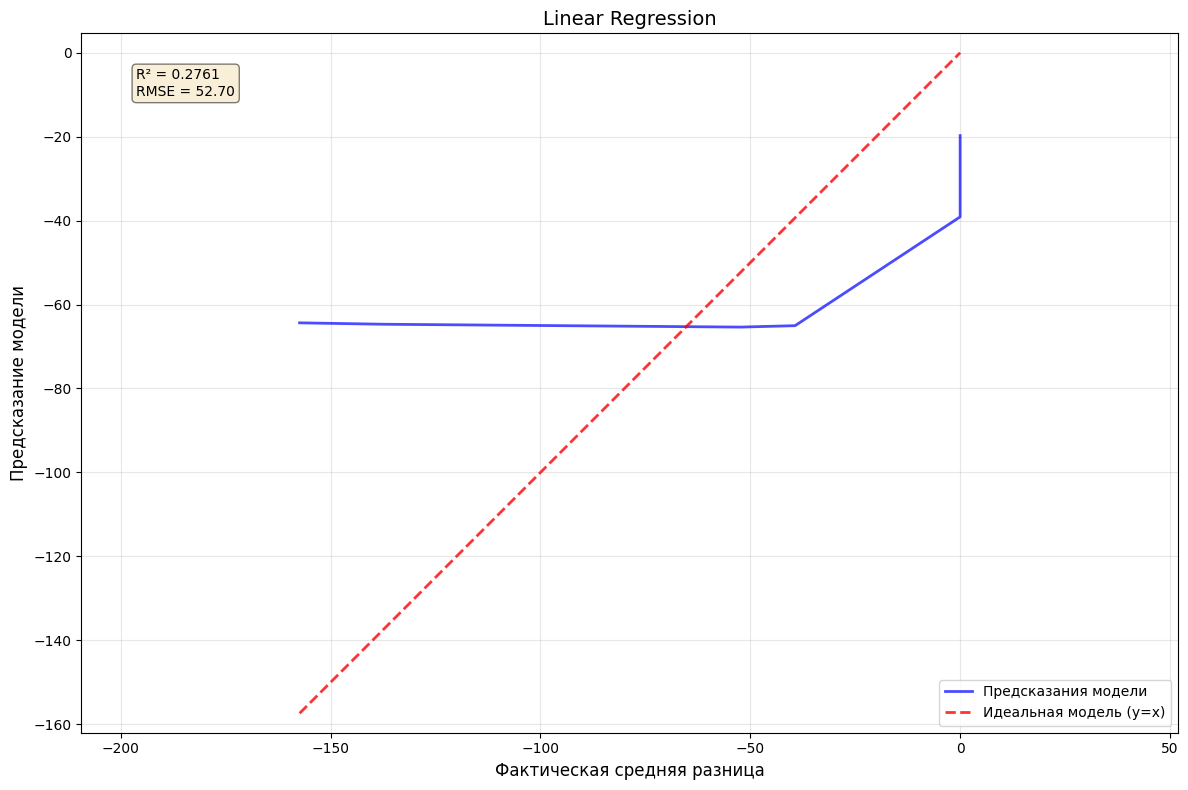

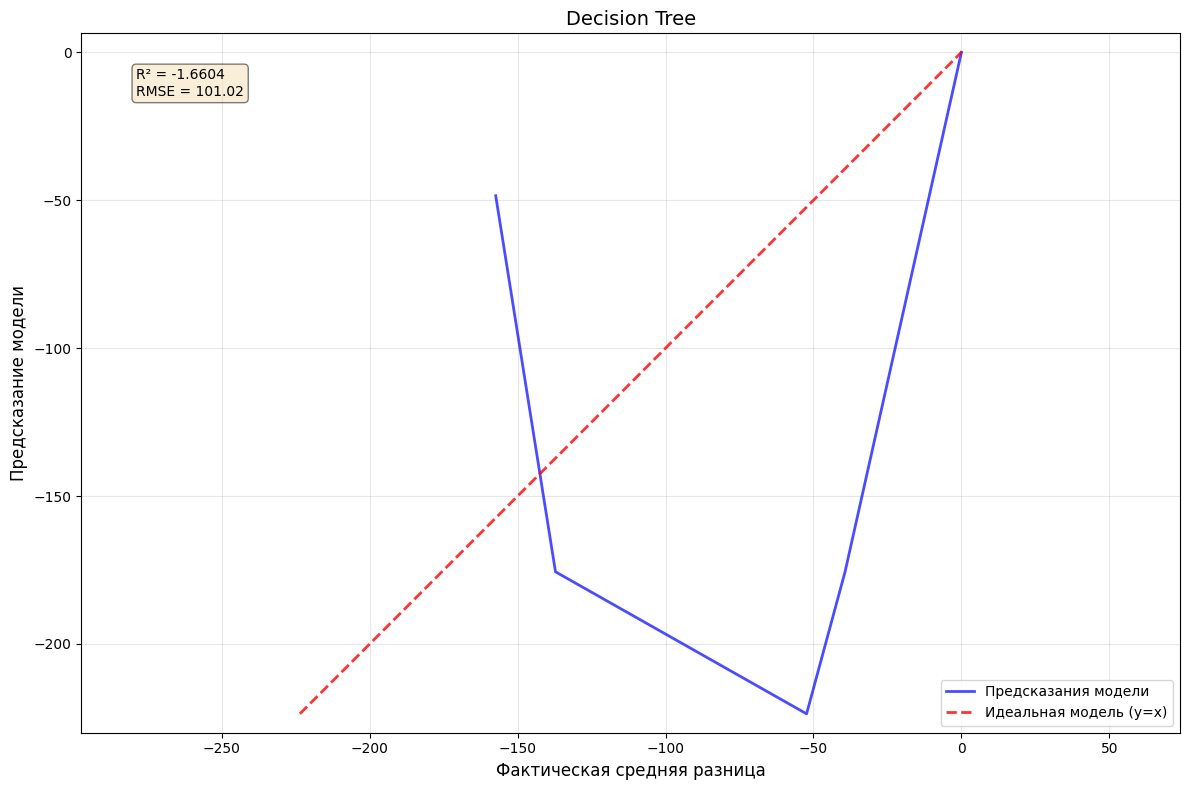

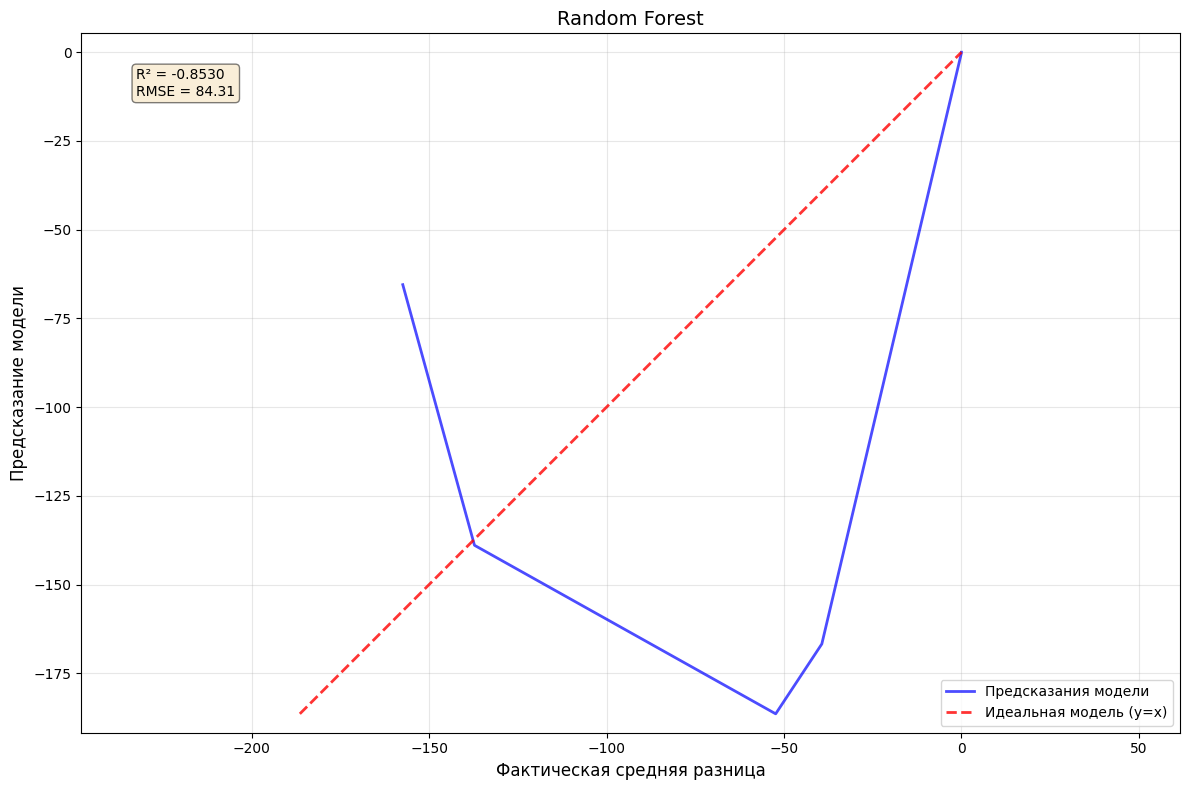

In [14]:
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = plot_predictions(model, X_test, y_test, name)

y = x